#  Jupyter notebook keeping track of all the steps followed in this project

# 1. Data Acquisition

We first downloaded the **legacy `.pdb` file** of *lysozyme (1LYZ)* from the Protein Data Bank:

https://www.rcsb.org/

We then visually inspected the structure in PyMOL to identify **five surface-exposed residues**, which were subsequently mutated to generate new protein sequences using ColabFold.

The code below performs the changes visually identified and stores them in ./lysozyme/sequences

In [49]:
from pathlib import Path

#Lysozyme sequence from PDB 1LYZ
wt = (
    "KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTP"
    "GSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL"
)

mutations = {
    # R21E: Arginine positive → Glutamate negative
    # Strong surface charge reversal; useful for testing electrostatic effects
    "R21E": (21, "R", "E"),

    # Q41E: Glutamine neutral polar → Glutamate negative
    # Adds negative charge while keeping similar size/polar character
    "Q41E": (41, "Q", "E"),


    # P70A: Proline rigid → Alanine flexible
    # Tests local backbone flexibility, especially if surface loop-exposed
    "P70A": (70, "P", "A"),

    # G102D: Glycine small/flexible → Aspartate charged
    # Adds negative charge and size at a flexible position
    "G102D": (102, "G", "D"),


    # T118F: Threonine polar → Phenylalanine hydrophobic/bulky
    # Creates a hydrophobic surface patch
    "T118F": (118, "T", "F"),
}

outdir = Path("./lysozyme/sequences")
outdir.mkdir(exist_ok=True)

def mutate_sequence(seq, position, old, new):
    index = position - 1  # convert from 1-based residue number to Python index
    if seq[index] != old:
        raise ValueError(
            f"Expected {old} at position {position}, but found {seq[index]}"
        )
    return seq[:index] + new + seq[index + 1:]

# write wild type
with open(outdir / "wt.fasta", "w") as f:
    f.write(">1LYZ_wt\n")
    f.write(wt + "\n")

# write mutants
for name, (position, old, new) in mutations.items():
    mutant_seq = mutate_sequence(wt, position, old, new)

    with open(outdir / f"1LYZ_{name}.fasta", "w") as f:
        f.write(f">1LYZ_{name}\n")
        f.write(mutant_seq + "\n")

    print(name, mutant_seq[position - 1])


R21E E
Q41E E
P70A A
G102D D
T118F F


## ColabFold results and DSSP secondary-structure annotation

This script processes the best ColabFold models (`rank_001`) for the sturcures of each mutation and the experimental structure (`1LYZ.pdb`) to:

- assign secondary structure using DSSP  
- identify helix, beta-strand, and coil/loop segments  
- count the number of segments  
- write modified PDB files with secondary structure encoded in the B-factor  

B-factor encoding:
- 1.0 → helix  
- 2.0 → beta strand  
- 3.0 → coil  

A temporary PDB with a valid `HEADER` is created for DSSP compatibility.

Outputs:
- annotated PDB files in `./lysozyme/best_models_with_ss/`  
- summary table: `secondary_structure_summary.csv`  

These PDBs can be visualized in PyMOL by mapping B-factors to secondary structure.

In [59]:
from pathlib import Path
import pandas as pd

from Bio.PDB import PDBParser, PDBIO
from Bio.PDB.DSSP import DSSP


input_dir = Path("./lysozyme/colabfold_results")
output_dir = Path("./lysozyme/best_models_with_ss")
output_dir.mkdir(exist_ok=True)

# Find best ColabFold models
pdb_files = sorted(input_dir.glob("*_unrelaxed_rank_001_*.pdb"))

# Also include experimental WT structure
pdb_files.append(Path("./lysozyme/1LYZ.pdb"))


def simplify_dssp(ss):
    if ss in ["H", "G", "I"]:
        return "H"   # helix
    elif ss == "E":
        return "E"   # beta strand
    else:
        return "C"   # coil/loop


ss_map = {
    "H": 1.0,
    "E": 2.0,
    "C": 3.0,
}


def get_segments(ss_data, target_state):
    segments = []
    start = None
    previous_res_id = None
    previous_chain = None

    for chain_id, res_id, resname, ss in ss_data:
        state = simplify_dssp(ss)

        if previous_chain is not None and chain_id != previous_chain:
            if start is not None:
                segments.append((previous_chain, start, previous_res_id))
                start = None

        if state == target_state and start is None:
            start = res_id

        elif state != target_state and start is not None:
            segments.append((chain_id, start, previous_res_id))
            start = None

        previous_res_id = res_id
        previous_chain = chain_id

    if start is not None:
        segments.append((previous_chain, start, previous_res_id))

    return segments


summary_rows = []
parser = PDBParser(QUIET=True)

for pdb_file in pdb_files:
    name = pdb_file.stem
    print(f"\nProcessing: {name}")

    # DSSP/Biopython needs a valid PDB HEADER line
    tmp_pdb = output_dir / f"{name}_tmp_for_dssp.pdb"

    with open(pdb_file, "r") as infile, open(tmp_pdb, "w") as outfile:
        lines = infile.readlines()

        first_nonempty = next((line for line in lines if line.strip()), "")

        if first_nonempty.startswith("HEADER"):
            outfile.writelines(lines)
        else:
            outfile.write("HEADER    GENERATED TEMP FILE FOR DSSP              01-JAN-00   TEMP\n")
            outfile.writelines(lines)

    structure = parser.get_structure(name, tmp_pdb)
    model = structure[0]

    dssp = DSSP(model, str(tmp_pdb), dssp="mkdssp", file_type="PDB")
    
    ss_data = []

    for key in dssp.keys():
        chain_id = key[0]
        res_id = key[1][1]
        resname = dssp[key][1]
        ss = dssp[key][2]

        ss_data.append((chain_id, res_id, resname, ss))

    helix_segments = get_segments(ss_data, "H")
    beta_segments = get_segments(ss_data, "E")
    coil_segments = get_segments(ss_data, "C")

    print("Helix segments:", helix_segments)
    print("Beta-strand segments:", beta_segments)
    print("Coil/loop segments:", coil_segments)

    print("Number of helices:", len(helix_segments))
    print("Number of beta strands:", len(beta_segments))
    print("Number of coil/loop regions:", len(coil_segments))

    # Write simplified secondary structure into B-factor column
    for chain in model:
        for residue in chain:
            key = (chain.id, residue.id)

            if key in dssp:
                raw_ss = dssp[key][2]
                simplified_ss = simplify_dssp(raw_ss)
                value = ss_map[simplified_ss]

                for atom in residue:
                    atom.set_bfactor(value)

    output_pdb = output_dir / f"{name}_with_ss.pdb"

    with open(output_pdb, "w") as f:
        f.write("HEADER    GENERATED BY BIOPYTHON WITH DSSP SECONDARY STRUCTURE\n")
        io = PDBIO()
        io.set_structure(structure)
        io.save(f)

    summary_rows.append({
        "model": name,
        "input_pdb": str(pdb_file),
        "output_pdb": str(output_pdb),
        "n_helices": len(helix_segments),
        "n_beta_strands": len(beta_segments),
        "n_coils": len(coil_segments),
        "helix_segments": helix_segments,
        "beta_segments": beta_segments,
        "coil_segments": coil_segments,
    })

    # Remove temporary file
    tmp_pdb.unlink()


summary = pd.DataFrame(summary_rows)
summary.to_csv(output_dir / "secondary_structure_summary.csv", index=False)

print("\nDone.")
print(f"Saved modified PDBs to: {output_dir}")
print(f"Saved summary to: {output_dir / 'secondary_structure_summary.csv'}")


Processing: 1LYZ_G102D_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Helix segments: [('A', 5, 14), ('A', 25, 36), ('A', 80, 84), ('A', 89, 99), ('A', 104, 107), ('A', 109, 114), ('A', 120, 124)]
Beta-strand segments: [('A', 43, 45), ('A', 51, 53), ('A', 58, 59)]
Coil/loop segments: [('A', 1, 4), ('A', 15, 24), ('A', 37, 42), ('A', 46, 50), ('A', 54, 57), ('A', 60, 79), ('A', 85, 88), ('A', 100, 103), ('A', 108, 108), ('A', 115, 119), ('A', 125, 129)]
Number of helices: 7
Number of beta strands: 3
Number of coil/loop regions: 11

Processing: 1LYZ_P70A_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Helix segments: [('A', 5, 14), ('A', 25, 36), ('A', 80, 84), ('A', 89, 100), ('A', 104, 107), ('A', 109, 114), ('A', 120, 123)]
Beta-strand segments: [('A', 43, 45), ('A', 51, 53), ('A', 58, 59)]
Coil/loop segments: [('A', 1, 4), ('A', 15, 24), ('A', 37, 42), ('A', 46, 50), ('A', 54, 57), ('A', 60, 79), ('A', 85, 88), ('A', 101, 103), ('A', 108, 108), ('A', 115, 119), ('A', 124, 129

# Analysis of surface properties of WT and mutants

In [64]:
from pathlib import Path
import pandas as pd
import freesasa

input_dir = Path("./lysozyme/best_models_with_ss")
analysis_dir = Path("./lysozyme/analysis")
analysis_dir.mkdir(exist_ok=True)

output_csv = analysis_dir / "surface_properties.csv"

pdb_files = sorted(input_dir.glob("*_with_ss.pdb"))

hydrophobic = {"ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP", "TYR", "PRO"}
positive = {"LYS", "ARG", "HIS"}
negative = {"ASP", "GLU"}

exposure_cutoff = 20.0  # Å²

rows = []

for pdb_file in pdb_files:
    model_name = pdb_file.stem.replace("_with_ss", "")
    print(f"Processing: {model_name}")

    structure = freesasa.Structure(str(pdb_file))
    result = freesasa.calc(structure)

    # collect residue-level SASA
    residue_sasa = {}

    for i in range(structure.nAtoms()):
        chain = structure.chainLabel(i)
        resnum = structure.residueNumber(i)
        resname = structure.residueName(i)

        key = (chain, resnum, resname)

        area = result.atomArea(i)

        residue_sasa[key] = residue_sasa.get(key, 0.0) + area

    exposed_residues = []
    hydrophobic_surface = []
    positive_surface = []
    negative_surface = []

    for (chain, resnum, resname), sasa in residue_sasa.items():
        if sasa >= exposure_cutoff:
            label = f"{chain}:{resname}{resnum}"
            exposed_residues.append(label)

            if resname in hydrophobic:
                hydrophobic_surface.append(label)

            if resname in positive:
                positive_surface.append(label)

            if resname in negative:
                negative_surface.append(label)

    rows.append({
        "model": model_name,
        "n_exposed_residues": len(exposed_residues),
        "n_hydrophobic_surface_residues": len(hydrophobic_surface),
        "n_positive_surface_residues": len(positive_surface),
        "n_negative_surface_residues": len(negative_surface),
        "net_surface_charge_count": len(positive_surface) - len(negative_surface),
    })

surface_df = pd.DataFrame(rows)
surface_df.to_csv(output_csv, index=False)

surface_df

Processing: 1LYZ_G102D_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Processing: 1LYZ_P70A_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Processing: 1LYZ_Q41E_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Processing: 1LYZ_R21E_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Processing: 1LYZ_T118F_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000
Processing: wt_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_000


,model,n_exposed_residues,n_hydrophobic_surface_residues,n_positive_surface_residues,n_negative_surface_residues,net_surface_charge_count
0,1LYZ_G102D_unrelaxed_rank_001_alphafold2_ptm_m...,82,20,18,10,8
1,1LYZ_P70A_unrelaxed_rank_001_alphafold2_ptm_mo...,82,20,18,9,9
2,1LYZ_Q41E_unrelaxed_rank_001_alphafold2_ptm_mo...,81,20,18,10,8
3,1LYZ_R21E_unrelaxed_rank_001_alphafold2_ptm_mo...,83,20,17,10,7
4,1LYZ_T118F_unrelaxed_rank_001_alphafold2_ptm_m...,82,21,18,9,9
5,wt_unrelaxed_rank_001_alphafold2_ptm_model_5_s...,81,20,18,9,9


# Plots of surface properties 

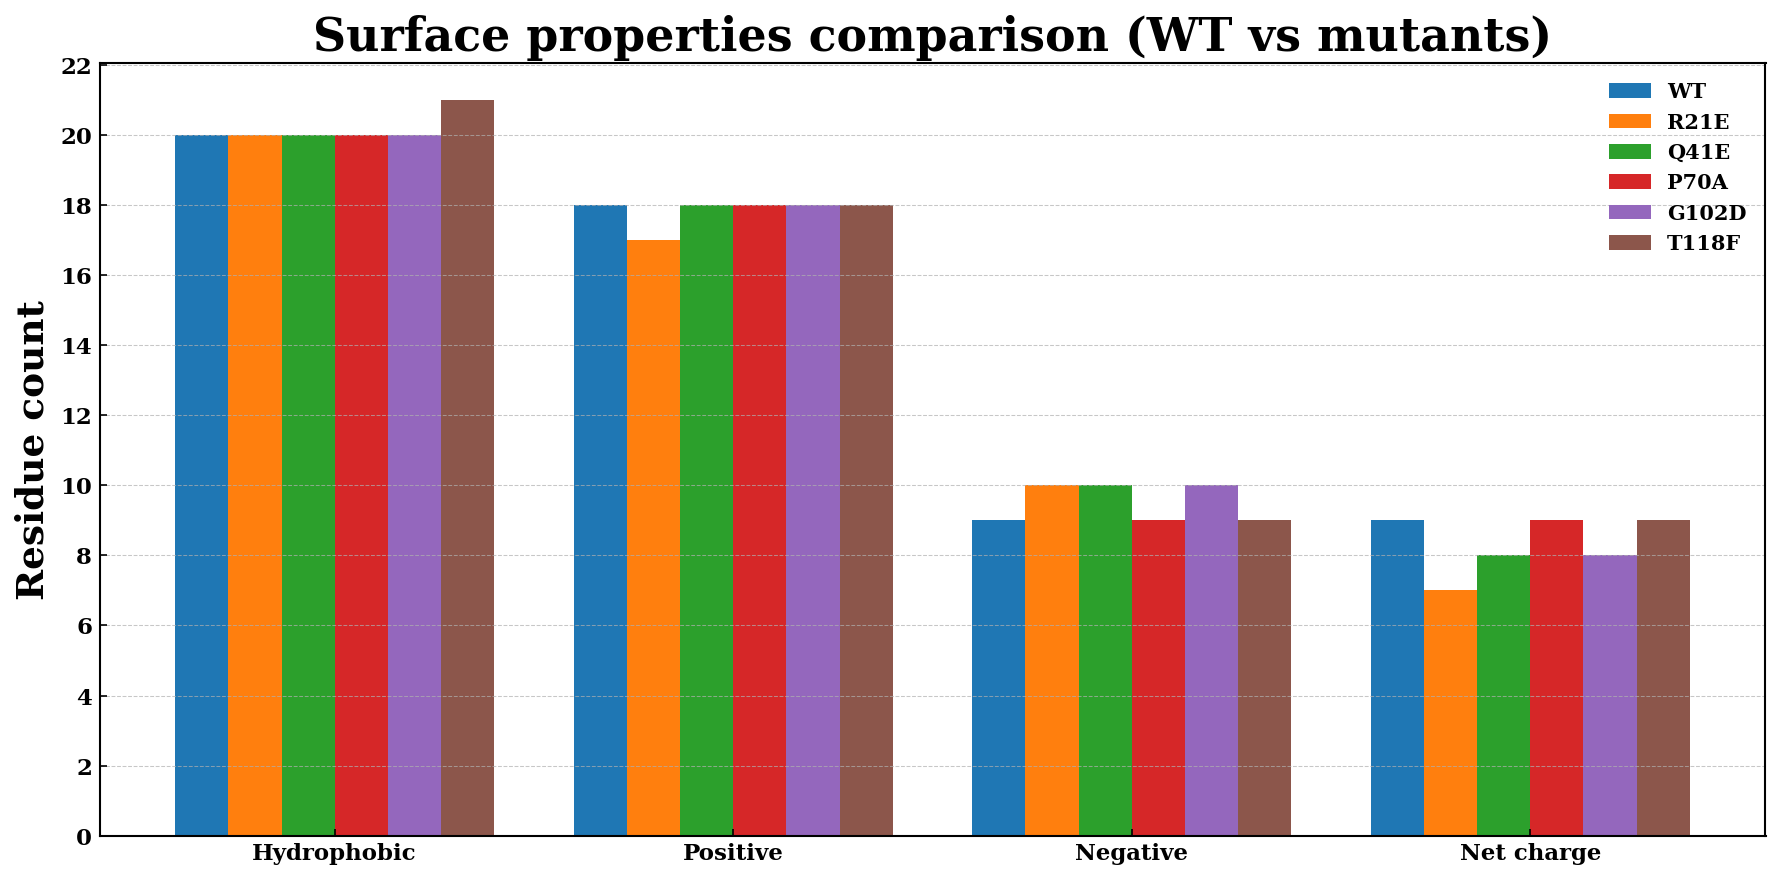

In [78]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib.ticker as ticker

plt.style.use("./plot_style.mplstyle")

analysis_dir = Path("./lysozyme/analysis")
df = pd.read_csv(analysis_dir / "surface_properties.csv")

# Clean names
def clean_name(name):
    if name.startswith("wt"):
        return "WT"
    if "1LYZ_" in name:
        return name.split("1LYZ_")[1].split("_")[0]
    return name

df["model_clean"] = df["model"].apply(clean_name)

# Extract residue number for sorting
def extract_position(name):
    if name == "WT":
        return -1  # ensures WT comes first
    match = re.search(r"\d+", name)
    return int(match.group()) if match else 999

df["position"] = df["model_clean"].apply(extract_position)

# Sort dataframe
df = df.sort_values("position").reset_index(drop=True)

# Properties
properties = [
    "n_hydrophobic_surface_residues",
    "n_positive_surface_residues",
    "n_negative_surface_residues",
    "net_surface_charge_count",
]

prop_labels = [
    "Hydrophobic",
    "Positive",
    "Negative",
    "Net charge",
]

models = df["model_clean"].tolist()
n_models = len(models)
n_props = len(properties)

x = np.arange(n_props)
bar_width = 0.8 / n_models

plt.figure(figsize=(12, 6))

for i, row in df.iterrows():
    values = row[properties].values
    positions = x - 0.4 + i * bar_width + bar_width / 2
    plt.bar(positions, values, width=bar_width, label=row["model_clean"])

plt.xticks(x, prop_labels)
plt.ylabel("Residue count")
plt.title("Surface properties comparison (WT vs mutants)")

# ✔ ticks every 2
ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

# ✔ grid (light, physics-style)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

    # R21E: Arginine positive → Glutamate negative
    # Strong surface charge reversal; useful for testing electrostatic effects

    # Q41E: Glutamine neutral polar → Glutamate negative
    # Adds negative charge while keeping similar size/polar character


    # P70A: Proline rigid → Alanine flexible
    # Tests local backbone flexibility, especially if surface loop-exposed

    # G102D: Glycine small/flexible → Aspartate charged
    # Adds negative charge and size at a flexible position


    # T118F: Threonine polar → Phenylalanine hydrophobic/bulky
    # Creates a hydrophobic surface patch

# Archive code

# Calculating number of helices and beta-strands using DSSP

In [61]:
from Bio.PDB import PDBParser
from Bio.PDB.DSSP import DSSP

pdb_file = "./lysozyme/1LYZ.pdb"
pdb_file = "./lysozyme/best_models_with_ss/1LYZ_with_ss.pdb"

parser = PDBParser(QUIET=True)
structure = parser.get_structure("prot", pdb_file)
model = structure[0]

dssp = DSSP(model, pdb_file, dssp="mkdssp")

# Extract residue number and DSSP secondary structure code
ss_data = []

for key in dssp.keys():
    chain_id = key[0]
    res_id = key[1][1]
    resname = dssp[key][1]
    ss = dssp[key][2]

    ss_data.append((res_id, resname, ss))

def simplify_dssp(ss):
    if ss in ["H", "G", "I"]:
        return "H"
    elif ss == "E":
        return "E"
    else:
        return "C"

def get_segments(ss_data, target_state):
    segments = []
    start = None
    previous_res_id = None

    for res_id, resname, ss in ss_data:
        state = simplify_dssp(ss)

        if state == target_state and start is None:
            start = res_id

        elif state != target_state and start is not None:
            segments.append((start, previous_res_id))
            start = None

        previous_res_id = res_id

    if start is not None:
        segments.append((start, previous_res_id))

    return segments

print(ss_data)
helix_segments = get_segments(ss_data, "H")
beta_segments = get_segments(ss_data, "E")
coil_segments = get_segments(ss_data, "C")

print("Helix segments:", helix_segments)
print("Number of helices:", len(helix_segments))

print("Beta-strand segments:", beta_segments)
print("Number of beta strands:", len(beta_segments))

print("Coil/loop segments:", coil_segments)
print("Number of coil/loop regions:", len(coil_segments))



[(1, 'K', '-'), (2, 'V', 'B'), (3, 'F', '-'), (4, 'G', '-'), (5, 'R', 'H'), (6, 'C', 'H'), (7, 'E', 'H'), (8, 'L', 'H'), (9, 'A', 'H'), (10, 'A', 'H'), (11, 'A', 'H'), (12, 'M', 'H'), (13, 'K', 'H'), (14, 'R', 'H'), (15, 'H', 'T'), (16, 'G', 'T'), (17, 'L', '-'), (18, 'D', 'T'), (19, 'N', 'T'), (20, 'Y', 'B'), (21, 'R', 'T'), (22, 'G', 'T'), (23, 'Y', 'B'), (24, 'S', '-'), (25, 'L', 'T'), (26, 'G', 'H'), (27, 'N', 'H'), (28, 'W', 'H'), (29, 'V', 'H'), (30, 'C', 'H'), (31, 'A', 'H'), (32, 'A', 'H'), (33, 'K', 'H'), (34, 'F', 'H'), (35, 'E', 'H'), (36, 'S', 'H'), (37, 'N', 'T'), (38, 'F', 'T'), (39, 'N', 'B'), (40, 'T', 'S'), (41, 'Q', 'S'), (42, 'A', '-'), (43, 'T', 'E'), (44, 'N', 'E'), (45, 'R', 'E'), (46, 'N', '-'), (47, 'T', 'T'), (48, 'D', 'T'), (49, 'G', 'S'), (50, 'S', '-'), (51, 'T', 'E'), (52, 'D', 'E'), (53, 'Y', 'E'), (54, 'G', 'T'), (55, 'I', 'T'), (56, 'L', 'T'), (57, 'Q', 'T'), (58, 'I', 'E'), (59, 'N', 'E'), (60, 'S', 'T'), (61, 'R', 'T'), (62, 'W', 'T'), (63, 'W', 'S'), 

# Changing pdb file to show secondary structure in Pymol calculated according DSSP

In [ ]:
from Bio.PDB import PDBParser, PDBIO
from Bio.PDB.DSSP import DSSP

pdb_file = "./lysozyme/1LYZ.pdb"

parser = PDBParser(QUIET=True)
structure = parser.get_structure("prot", pdb_file)
model = structure[0]

dssp = DSSP(model, pdb_file, dssp="mkdssp")

def simplify_dssp(ss):
    if ss in ["H", "G", "I"]:
        return "H"   # helix
    elif ss == "E":
        return "E"   # beta strand
    else:
        return "C"   # coil/loop

# Map simplified SS → numeric B-factor value
# 1.0 = helix
# 2.0 = beta strand
# 3.0 = coil/loop
ss_map = {
    "H": 1.0,
    "E": 2.0,
    "C": 3.0,
}

for chain in model:
    for residue in chain:
        res_id = residue.id
        key = (chain.id, res_id)
        if key in dssp:
            raw_ss = dssp[key][2]
            simplified_ss = simplify_dssp(raw_ss)
            value = ss_map[simplified_ss]

            for atom in residue:
                atom.set_bfactor(value)

output_file = "./lysozyme/1LYZ_with_ss.pdb"

with open(output_file, "w") as f:
    f.write("HEADER    GENERATED BY BIOPYTHON\n")

    io = PDBIO()
    io.set_structure(structure)
    io.save(f)